# Capstone: Define and Solve an ML Problem

In [31]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename, header=0)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

(1) I chose the census dataset, which contains demographic and employment information from the 1994 U.S. Census. 

(2) My label column is income_binary, which contains two values: <=50K and >50K. I am predicting whether an indiviual's income exceeds 50k, the output will be binary (0 and 1).

(3) I plan to use these features: age, workclass, education, education-num, maritial status, occupation, relationship, race, sex_selfID, capital-gain, capital-loss, hours-per-week, and native-country.

(4) A ML model can help case managers quickly and effortlessly identify whether a indiviual qualifies for financial assistance programs. It also eliminates the inconsistency between different case managers, and offers a scalable solution. The model would be an aide to case managers, who can use the model to predict whether an indiviual's income will fall below or over 50k, and subsequently whether the indiviual is qualified for their low-interest loans.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

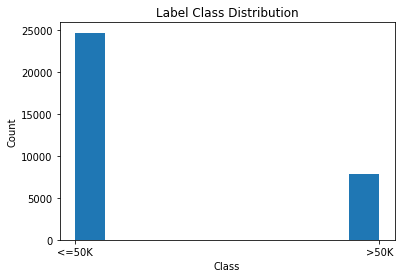

<=50K    0.76
>50K     0.24
Name: income_binary, dtype: float64


In [3]:
plt.hist(df['income_binary'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Label Class Distribution')
plt.show()

print(df['income_binary'].value_counts(1).round(2))

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [5]:
# mean and median differ greatly for capital_gain and capital_loss
# check for redundant zeroes
zero_count_percent_gain = ((df['capital-gain'] == 0).sum()/df['capital-gain'].count()).round(3)
zero_count_percent_loss = ((df['capital-loss'] == 0).sum()/df['capital-loss'].count()).round(3)
print(f'percent of values =0 in capital gain: {zero_count_percent_gain}')
print(f'percent of values =0 in capital loss: {zero_count_percent_loss}')
# to-do: create binary columns (0 if no gain, 1 if any gain)

percent of values =0 in capital gain: 0.917
percent of values =0 in capital loss: 0.953


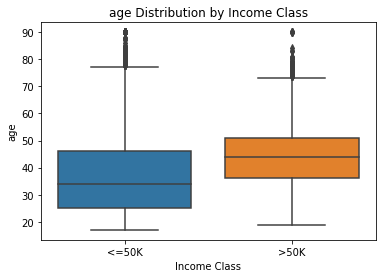

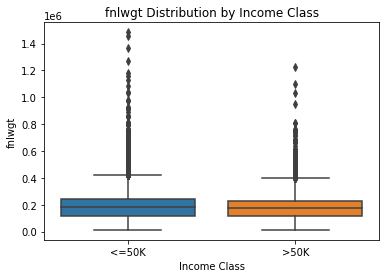

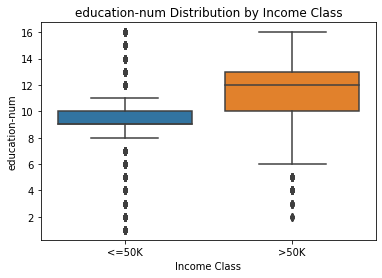

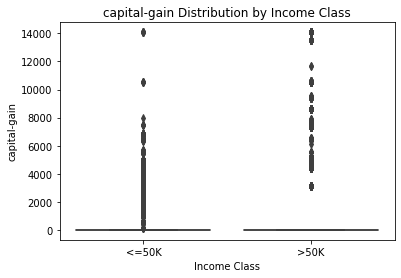

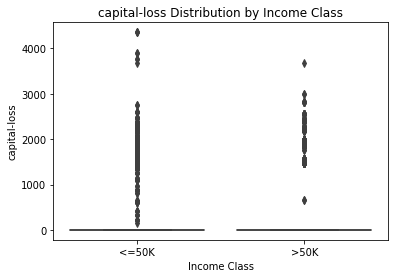

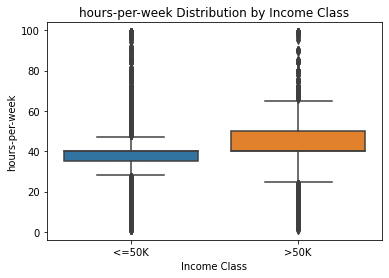

In [6]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    if col != 'income_binary': 
        sns.boxplot(x=df['income_binary'], y=df[col])
        
        plt.xlabel('Income Class')
        plt.ylabel(col)
        plt.title(f'{col} Distribution by Income Class')
        
        plt.show()

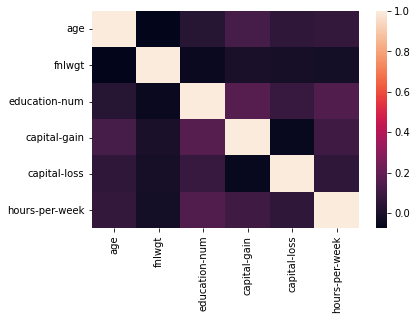

In [7]:
# based on heatmap, correlation is low except diagnol, so no labels are redundant
corr = df.corr()
sns.heatmap(corr)
plt.show()

In [8]:
categorical = list([col for col in df.columns if df[col].dtypes == 'O'])
numerical = list([col for col in df.columns if df[col].dtypes != 'O'])
print(f'categorical columns(one-hot encoding required): {categorical}')
print(f'numerical columns: {numerical}')

categorical columns(one-hot encoding required): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID', 'native-country', 'income_binary']
numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [9]:
# hot encoding only for columns with low unique count
df_filtered = df.loc[:, df.nunique() < 20]
df_filtered.columns

Index(['workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex_selfID', 'income_binary'],
      dtype='object')

In [10]:
# display labels with missing values
df_filtered.isnull().sum()

workclass         1836
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
income_binary        0
dtype: int64

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

I noticed that I have to drop some categorical columns that have more than 20 unique values, since encoding them would be costly. I also found that the capital gain and captial loss labels were mostly filled with 0s, so I am deciding to drop them. Lastly, I found that there are many missing values in the 'workclass' and 'occupation', so I will handle those with the dropna() method.

To adress the class inbalance in the label class, I will use the F1 score to evaluate the model, and also set the DecisionTree parameter 'class_weight' to 'balanced'.

1. What data preparation techniques would you like to use? 

    I will need to use one-hot encoding for categorical values, winsorization for outliers, dropping the 'fnlwgt' column (too many columns to encode), and address class imbalance by using different evalutation metrics (recall and percision).


2. What machine learning model would you like to use that is suitable for your predictive problem and data?

    I will use DecisionTree because the data is mostly categorical and the data is not well defined by one relationship/function, therefore DecisionTree will be effective at idenitfying by features.


3. How will you evaluate and improve the model's performance?

    I will use cross-validation and F1 score to test for consistency over different sets. I will use grid-search to optimize and improve model performance.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

(1) Features like race and sex may impose a historical bias, and isn't always an indicitive factor in determining income. It is also important to consider that the dataset is from the 1994 census, which isn't very recent. If possible we want to use the latest census data.

(2) If a model makes an incorrect prediciton, the indivuals seeking the loan will be most at risk. If the model fails to correctly classify an indiviual's income, then they may be unable to pursue an oppurtunity or they will need to find another firm that charges higher interest. Since the model is also used to target audiences, it may lead to a decrease in loans lended, and consequently less profit overtime. Although this model is intended for large scale, it should be regularly maintained and human input should be used when neccescary.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
# drop fnlwgt column
df.drop(columns='fnlwgt', inplace=True) # fnlwgt is not relevant to income, and may skew data

# drop education column
df.drop(columns='education', inplace=True) # education is redudant with education-num, they represent the same thing

# drop categorical columns with more than 20 unique values (unsuitable for one hot encoding)
cols_to_drop = df.columns[(df.nunique() > 20) & (df.dtypes == 'object')]
df.drop(columns=cols_to_drop, inplace=True)

In [12]:
# locate missing values
nan_count = np.sum(df.isnull(), axis = 0)
nan_count

age                162
workclass         1836
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
income_binary        0
dtype: int64

In [13]:
# use fillna to fill in missing values with mean value for age and hours-per-week
mean_ages=df['age'].mean()
mean_hours = df['hours-per-week'].mean()
df['age'].fillna(value=mean_ages, inplace=True)
df['hours-per-week'].fillna(value=mean_hours, inplace=True)

In [14]:
# fill in missing workclass and occupation values
df['workclass'] = df['workclass'].fillna('Unknown', inplace=True)
df['occupation'] = df['occupation'].fillna('Unknown', inplace=True)

In [15]:
# locate columns with extreme outliers
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    print(f"\n{col}")
    print(df[col].quantile([0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]))


age
0.00    17.0
0.01    17.0
0.05    19.0
0.50    37.0
0.95    63.0
0.99    74.0
1.00    90.0
Name: age, dtype: float64

education-num
0.00     1.0
0.01     3.0
0.05     5.0
0.50    10.0
0.95    14.0
0.99    16.0
1.00    16.0
Name: education-num, dtype: float64

capital-gain
0.00        0.0
0.01        0.0
0.05        0.0
0.50        0.0
0.95     5013.0
0.99    14084.0
1.00    14084.0
Name: capital-gain, dtype: float64

capital-loss
0.00       0.0
0.01       0.0
0.05       0.0
0.50       0.0
0.95       0.0
0.99    1980.0
1.00    4356.0
Name: capital-loss, dtype: float64

hours-per-week
0.00     1.0
0.01     8.0
0.05    18.0
0.50    40.0
0.95    60.0
0.99    80.0
1.00    99.0
Name: hours-per-week, dtype: float64


In [16]:
# winsorize capital-gain and capital-loss columns by 5%
from scipy.stats.mstats import winsorize

df['capital-gain'] = winsorize(
    df['capital-gain'],
    limits=[0.05, 0.05]
)

df['capital-loss'] = winsorize(
    df['capital-loss'],
    limits=[0.05, 0.05]
)

In [17]:
## One Hot Encoding

# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df[categorical_cols])

# Join encoded columns back
df = df.join(df_encoded)

# Drop original categorical columns
df.drop(columns=categorical_cols, inplace=True)

# Combine label column into one column with binary output
df['income_binary_>50k'] = df['income_binary_>50K']  # 1 = >50K, 0 = <=50K

# drop the old one-hot columns
df = df.drop(columns=['income_binary_<=50K', 'income_binary_>50K'])

# Preview columns
df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,...,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Inuit,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_selfID_Female,sex_selfID_Non-Female,income_binary_>50k
0,39.0,13,2174,0,40.0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,50.0,13,0,0,13.0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2,38.0,9,0,0,40.0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,53.0,7,0,0,40.0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
4,28.0,13,0,0,40.0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0


In [18]:
# create training and test sets
X = df.drop(columns=['income_binary_>50k'])
y = df['income_binary_>50k']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print(X_train.shape, X_test.shape)

(26048, 25) (6513, 25)


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

#### Class Imbalance
The class imbalance was not addressed in data preparation because in the next section I will set the DecisionTree classweight parameter to balanced, and later on during the evaluation stage I will use the F1 score to assure the model isn't skewed by the label.

#### Dropping Feature Columns
First, I decided to drop the 'fnlwgt' column based on hueristic: given that these values were estimated weights, I decided not to include them in my model. I also dropped the 'eductaion' column because since the 'education-num' column represents the same values. Lastly, I used list comprehension to filter out categorical rows with more than 20 unique values, since they would lead to too many rows after one hot encoding.

#### Missing Values
For the numerical feature columns 'age' and 'hours-per-week', I used fillna() to fill in the missing values with the average of the rest of the values. For the categorical values in 'workclass' and 'occupation' I filled the missing values with 'unknown'. I decided to fill in values rather than drop them because all data-points have a value in the label column, so they are worth as much as other data-points. I made sure to fill the values with mean and 'unkwown' to keep the distribution close to the original.

#### Handling Extreme Outliers
After list the top and bottom 5th percentile, I noticed a huge difference in the values from the mean in the 'capital-gain' and 'capital-loss' columns. I decided to winsorize with a limit of 5% for these columns since I didnt want the top or bottom 5 percent to dictate the rest of the column.

#### One Hot Encoding
I one hot encoded the remaining categorical columns since the DecisionTree model only accepts numerical values. I dropped the original categorical columns from the final dataset, so it doesn't interfere when creating labelled test sets and examples. Also, since our label column was originally categorical, one hot encoding split it into two columns. However, for simplicity I only kept one of the columns, which outputs 0 if less than or equal to 50k and 1 if over 50k.

#### Creating Training and Test Splits
After defining the label and feature columns, I used train_test_split() to create labelled test sets and examples. I set 20% for testing, and set a random seed so the results are consistent throughout trials of testing the model.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [19]:
# Create labeled examples from the dataset

# Already completed in Section 4 so code is commented out here
# X = df.drop(columns=['income_binary_>50k'])
# y = df['income_binary_>50k']

In [20]:
# Create training and test sets out of the labeled examples 

# Already completed in Section 4 so code is commented out here
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [21]:
# Train, test and evaluate your default model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
class_label_predictions = model.predict(X_test)
f1 = f1_score(y_test, class_label_predictions, average='binary')
acc_score = accuracy_score(class_label_predictions, y_test)

print('Accuracy score: {0}'.format(acc_score))
print('F1 score: {0}'.format(f1))

Accuracy score: 0.8109933978197451
F1 score: 0.5848229342327151


In [22]:
from sklearn.model_selection import cross_val_score

# Perform cross validation on model with balanced weight
balanced_model = model = DecisionTreeClassifier(class_weight='balanced')
scores = cross_val_score(DecisionTreeClassifier(class_weight='balanced'), X_train, y_train, cv=5, scoring='f1')
print(scores)
print('Average F1:', scores.mean())

# Results show conistent model performance across different splits

[0.60082305 0.62141883 0.61554476 0.61043899 0.61253369]
Average F1: 0.612151863195869


In [23]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model

# set up parameter grid to search in
md = [2**n for n in range(2,6)]
msl = [25*2**n for n in range(0,3)]
param_grid={'max_depth':md, 'min_samples_leaf':msl}

# Run a Grid Search with 5-fold cross-validation using our the model.
# Pass all relevant parameters to GridSearchCV and assign the output to the object 'grid'
grid = GridSearchCV(balanced_model, param_grid, cv=5)

# Fit the model to the training data and assign the fitted model to the variable grid_search
grid_search = grid.fit(X_train, y_train)

best_md = grid_search.best_estimator_.max_depth
best_msl = grid_search.best_estimator_.min_samples_leaf

# Print best performing hyperparameter configuration
print('Best value for max depth: {0}'.format(best_md))
print('Best value for the minimum number of samples required to be at a leaf node: {0}'
      .format(best_msl))

# Print best accuracy score resulting from this configuration
print('Accuracy score: {0}'.format(grid_search.best_score_))

Best value for max depth: 32
Best value for the minimum number of samples required to be at a leaf node: 25
Accuracy score: 0.7962608935000658


In [24]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_model = DecisionTreeClassifier(max_depth=best_md, min_samples_leaf=best_msl, class_weight='balanced')
best_model.fit(X_train, y_train)
class_label_predictions = best_model.predict(X_test)
acc_score = accuracy_score(class_label_predictions, y_test)
print('Accuracy score: {0}'.format(acc_score))

Accuracy score: 0.7996315062183326


In [25]:
# Interpret your model's outputs 
# DecisionTree Top 5 important features

#1. Obtain "feature importance" scores from the model object 
feature_imp = best_model.feature_importances_

#2. Create a Pandas DataFrame with a list of all features and their scores. 
df_features = pd.DataFrame({'name':X_train.columns.values, 'imp':feature_imp})

#3. Sort df_features in descending order and
df_sorted = df_features.sort_values(by='imp', ascending=False)

#4. Obtain the top 5 sorted feature names and save the result to list 'top_five' 
top_five = df_sorted['name'].iloc[:5].tolist()
print('Top five features: {0}'.format(top_five))

Top five features: ['marital-status_Married-civ-spouse', 'education-num', 'capital-gain', 'age', 'hours-per-week']


Text(0, 0.5, 'Normalized importance')

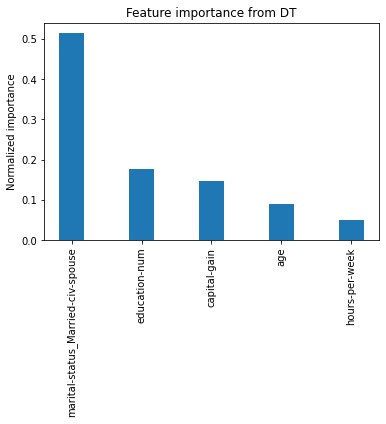

In [26]:
# Plot the top 5 most important features
fig, ax = plt.subplots()
ax.bar(np.arange(5), sorted(best_model.feature_importances_, reverse=True)[:5], width = 0.35)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(top_five, rotation = 90)
plt.title('Feature importance from DT')
ax.set_ylabel('Normalized importance')

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

(1) I chose the DecisionTreeClassifier model because of the non-linear nature of the data. Since there are many features to consider and the data doesn't follow any specific relationship, DecisionTree will be good at separating and making decisions by features.

(2) In the model selection process, I first performed cross-validation, which showed that my results stayed consistent through different split sets. Then performing grid search, I found the parameters with the best accuracy score. I made sure to set the classweight parameter to balanced, which helps increase F1 score and decrease class imbalance.

(3) I found the top 5 important features, and in the context of the bussiness problem, they represent the things the model relied on the most when making predictions. So when a case officer uses the ML model, they should know that maritial status, education, captial gain, age, and hours worked each week are weighing on the model's decision the most. Also it is a good sign that the model relies non-racial features, since it would otherwise be seen as discriminatory.

(4) Based on the most important feature, it seems like the model heavily relies on whether a person is married. Unmarried indiviuals might be more at risk of not getting a loan. Therefore, the case officer should take a second look when handling a case with an unmarried indiviual. There are no major ethical concerns with the model that regard topics like race or sex.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [37]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [38]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=(n_features,), name='input')
nn_model.add(input_layer)


# Create the hidden layers and add the hidden layers to the 'nn_model' object
# I will have 3 layers since any further is not worth the cost, and any less underperforms. 
# The first layer will have 64, then 32, then 16, since this is common practice
# I will use relu for the hidden layers since it avoids the vanishing gradient issue
# The output layer will use sigmoid since the output is a binary classification type

# Construct hidden layer 1, add to model
hidden_layer_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)

# Construct hidden layer 2, add to model
hidden_layer_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)

# Construct hidden layer 3, add to model
hidden_layer_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')
nn_model.add(hidden_layer_3)

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output') 
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hl_1 (Dense)                 (None, 64)                1664      
_________________________________________________________________
hl_2 (Dense)                 (None, 32)                2080      
_________________________________________________________________
hl_3 (Dense)                 (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 4,289
Trainable params: 4,289
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [63]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# I am using 0.01 since the data was previously scaled, the model does not need a high learning rate
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [64]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [65]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [66]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [67]:
t0 = time.time() # start time

# 100 epoch is a reasonable number of rounds to go through the data and avoid redundant noise 
num_epochs = 100 

# create unqiue class weights to counter label class imbalance
unique_classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced', 
    classes=unique_classes, 
    y=y_train
)
# format for keras
class_weights = dict(zip(unique_classes, weights))

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0, # disable the default progress bar
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
    validation_split=0.2,
    class_weight = class_weights
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.4023, Accuracy: 0.7916, Val_loss: 0.4623, Val_accuracy: 0.7591
Epoch [20/ 100], Loss: 0.3929, Accuracy: 0.7914, Val_loss: 0.3548, Val_accuracy: 0.8257
Epoch [30/ 100], Loss: 0.3890, Accuracy: 0.7939, Val_loss: 0.5047, Val_accuracy: 0.7399
Epoch [40/ 100], Loss: 0.3859, Accuracy: 0.7952, Val_loss: 0.3785, Val_accuracy: 0.8084
Epoch [50/ 100], Loss: 0.3836, Accuracy: 0.7960, Val_loss: 0.3892, Val_accuracy: 0.8046
Epoch [60/ 100], Loss: 0.3823, Accuracy: 0.7978, Val_loss: 0.4121, Val_accuracy: 0.7883
Epoch [70/ 100], Loss: 0.3812, Accuracy: 0.7978, Val_loss: 0.3767, Val_accuracy: 0.8132
Epoch [80/ 100], Loss: 0.3794, Accuracy: 0.8008, Val_loss: 0.4337, Val_accuracy: 0.7756
Epoch [90/ 100], Loss: 0.3780, Accuracy: 0.7992, Val_loss: 0.4205, Val_accuracy: 0.7877
Epoch [100/ 100], Loss: 0.3765, Accuracy: 0.7993, Val_loss: 0.4065, Val_accuracy: 0.7931
Elapsed time: 161.27s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



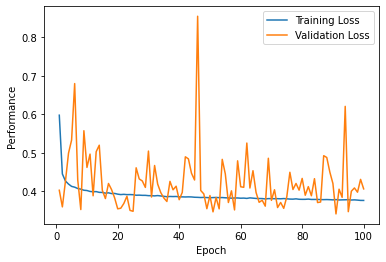

In [68]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()

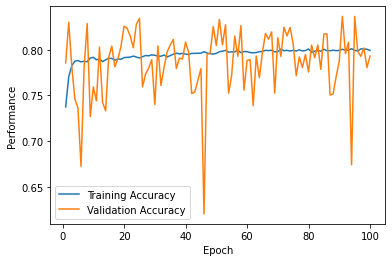

In [69]:
# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [70]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
class_label_predictions=[]
for i in range(0,len(y_test)):
    if probability_predictions[i] >= 0.5:
        class_label_predictions.append(1)
    else:
        class_label_predictions.append(0)

In [71]:
# FIX: F1 score is 0

# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, class_label_predictions)
nn_f1 = f1_score(y_test, class_label_predictions, average='binary')

print('Neural Network Accuracy: {0}'.format(nn_accuracy))
print('Neural Network F1 score: {0}'.format(nn_f1))

Neural Network Accuracy: 0.7997850452940273
Neural Network F1 score: 0.6778656126482214


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

(1) I decided to build three hidden layers because I found that in the Unit 6 assignment, three layers was just enough to train the model before additional costs in time and performance. Each hidden layer uses a relu function because it avoids the vanishing gradient issue. The first layer starts with 64 units and each layer has half the number of units, following the examples of other modules in this course. The last layer only has one unit with a sigmoid function since the label is a binary classification type. I set the learning rate relatively low at 0.01 because the data was scaled, and I didnt want my network to converge wildly. Finally, I decided on 100 epochs, since after 100 the model usually sees very marginal difference in any of the metrics(val_loss, vall_accuracy, etc.).

(2) There are no signs of overfitting, since the training and validation curves converge. There also isn't any major sign of underfitting, since the validation accuracy is pretty large, although it fluctuates. The fluctuation is likely due to the learning network, but I don't think it signifies underfitting. The graphs tells me that the validation curves are very noisy, likely due to the small 20% validation split. To improve this I could introduce momentum in the SGD optimizer.

(3) Neural Network Accuracy: 0.7997850452940273
    Neural Network F1 score: 0.6778656126482214
    The scores were not surprising since the accuracy and validation curves were in the range of 0.6-0.7 in the    graphs.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [75]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree Model': [acc_score, f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

   Metric  Decision Tree Model  Neural Network
 Accuracy             0.799632        0.799785
 F1 Score             0.584823        0.677866


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

(1) Both models had the same accuracy score, the nueral network was only higher by 0.0001, a trivial amount. The F1 score for neural networks was much higher, however, with almost a 0.10 difference.

(2) I think the neural network is not justified. Even though the F1 score is higher, it's still below standard (0.80+), and I think adjusting the parameters on a wider grid would show an improvement. The neural network also makes abstract decisions that are not directly observable.

(3) I would reccomend the DecisionTree model because although it lacks performance, it is the most interpretable and flexible. The company and stakeholders would be able to view the most important features used in the model, and choose will features they want to train with. DecisionTrees are also scalable, something that the company would benefit from as they expand. With thr right tweaks, DecisionTrees are the better model because of its interpretability, scalability, and flexibility.

(4) I would first try to address the class imbalance issue. This would entail finding new data or assigning custom weights (which I tried in NN section but not DT). I also want to test if the DecisionTree model performs better with fewer features or more features. I had to drop many of the features, so it wasn't possible in this session. I also want to try adding momentum and test different activation functions at each layer, to see if the accuracy and F1 score improve for the NN.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

(1) I used AI when brainstorming the data preparation stage and evaluating the Neural Network. In the data preparation stage, I used claude to outline the steps I should take to prepare my data. I only took steps that were relevant to my data and made sense. I appreciated the insight into the order of the steps, as cluade suggested to first drop columns and missing values. This way the dropped examples would not interfere with the rest of the preparation. Additionally, I used AI to debug the performance of my NN. Initially, I kept getting a F1 score of 0.0, which indicated my model was not identifying any true positives. Over the course of many prompts, I finally found the error: why fitting my model I used X_train instead of the scaled version 🤦. I also added custom weights using a numpy library suggested by claude, which addressed the class imbalance and additionally increased the F1 score.

(2) I felt like the data preparation took the most effort and thought since there was minimal guidance, many of the steps were upto my discretion. At first, I felt disorganized going right into it by randomly doing steps I learned from previous modules. But I was running into too many errors because I had no thought out plan. After asking claude to brainstorm a plan, prompting it with the steps I finished so far, it suggested a framework that felt executable. After that, I felt more organized and worked through the section dilligently.

(3) I made sure that the evalutation metrics were within the range I would like, specifically the accuracy and F1 score. Also I used my hueristics to make sure that nothing seemed out of place, for instance I knew that an F1 score of 0.0 indicates a major problem in my NN.

(4) Next time, if there are large sections where I have free agency to make decisions, I want to make sure to first make a plan before I start writing code. I would also like to run my plan through AI and pick up any improvements to my plan.